In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

# Task 1: Environment Exploration


In [2]:
import gymnasium as gym
import numpy as np

# ==================================================
# TASK 1: ENVIRONMENT EXPLORATION
# ==================================================

# --------------------------------------------------
# Step 1:
# Create the FrozenLake-v1 environment
# --------------------------------------------------

env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="ansi"
)

# --------------------------------------------------
# Step 2:
# Print the observation space and action space.
# Explain what each action index (0–3) means.
# --------------------------------------------------

print("========== FROZENLAKE ==========\n")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

print("\nAction Meanings:")
print("0 -> Left")
print("1 -> Down")
print("2 -> Right")
print("3 -> Up")

# --------------------------------------------------
# Step 3:
# Run 5 episodes with random actions.
# Print total reward and number of steps.
# --------------------------------------------------

for episode in range(1, 6):

    state, info = env.reset()

    done = False
    total_reward = 0
    steps = 0

    print(f"\n--- FrozenLake Episode {episode} ---")

    # --------------------------------------------------
    # Step 4:
    # Render and display the FrozenLake grid.
    # --------------------------------------------------

    print(env.render())

    while not done:

        # Random action selection
        action = env.action_space.sample()

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Check if episode finished
        done = terminated or truncated

        # Update reward and step count
        total_reward += reward
        steps += 1

        # Render updated grid
        print(env.render())

        # Update state
        state = next_state

    # Print episode results
    print(f"Total Reward: {total_reward}")
    print(f"Steps Taken: {steps}")

env.close()

# --------------------------------------------------
# Step 5:
# Repeat steps 1–3 for the Taxi-v3 environment.
# --------------------------------------------------

env = gym.make("Taxi-v4", render_mode="ansi")

print("\n\n========== TAXI ==========\n")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

print("\nAction Meanings:")
print("0 -> South")
print("1 -> North")
print("2 -> East")
print("3 -> West")
print("4 -> Pickup")
print("5 -> Dropoff")

for episode in range(1, 6):

    state, info = env.reset()

    done = False
    total_reward = 0
    steps = 0

    print(f"\n--- Taxi Episode {episode} ---")

    print(env.render())

    while not done:

        # Random action selection
        action = env.action_space.sample()

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Check if episode finished
        done = terminated or truncated

        # Update reward and step count
        total_reward += reward
        steps += 1

        # Render updated environment
        print(env.render())

        # Update state
        state = next_state

    # Print episode results
    print(f"Total Reward: {total_reward}")
    print(f"Steps Taken: {steps}")

env.close()

========== FROZENLAKE ==========

Observation Space: Discrete(16)
Action Space: Discrete(4)

Action Meanings:
0 -> Left
1 -> Down
2 -> Right
3 -> Up

--- FrozenLake Episode 1 ---

SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

Total Reward: 0
Steps Taken: 2

--- FrozenLake Episode 2 ---

SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

Total Reward: 0
Steps Taken: 2

--- FrozenLake Episode 3 ---

SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

Total Reward: 0
Steps Taken: 2

--- FrozenLake Episode 4 ---

SFFF
FHFH
FFFH
HFFG

  (Up)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

Total Reward: 0
Steps Taken: 5

--- FrozenLake Episode 5 ---

SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

Total Reward: 0
Steps Taken: 3


========== 

## Task 1: Environment Comparison — FrozenLake vs Taxi

### State Spaces
- **FrozenLake-v1 (4×4):** `Discrete(16)` — 16 states (one per grid cell, numbered 0–15).
- **Taxi-v4:** `Discrete(500)` — 500 states encoding the taxi's position (25 cells), the passenger's location (5 options: 4 pickup spots + in-taxi), and the destination (4 options). This is 25 × 5 × 4 = 500.

### Action Spaces
- **FrozenLake:** 4 actions — Left, Down, Right, Up.
- **Taxi:** 6 actions — South, North, East, West, Pickup, Dropoff.

### Why is Taxi harder than FrozenLake?
1. **State space is 31× larger** (500 vs 16), making exploration much more expensive.
2. **Sparse, delayed rewards:** In FrozenLake the agent just needs to reach the goal. In Taxi, the agent must first navigate to the passenger, pick them up, then navigate to the correct destination and drop them off — a multi-step sub-task chain that massively increases the credit-assignment problem.
3. **Illegal-action penalties:** Wrong pickups/dropoffs give −10 reward, adding noise that makes random exploration very inefficient.
4. **More actions to coordinate:** The two non-movement actions (Pickup, Dropoff) must be used at exactly the right time and place, or they are wasted/penalised.

In short: Taxi demands that the agent learn a *sequential sub-goal strategy* over a state space 31× larger than FrozenLake, with harsher penalties for mistakes — making it significantly harder to solve.

# Task 2: Q-Learning on FrozenLake


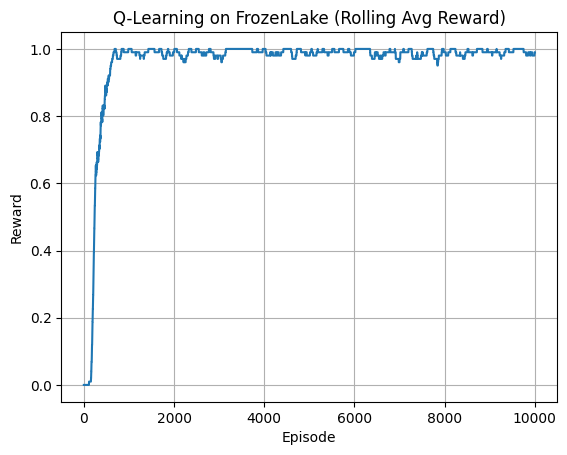

Final Q-table:

[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.65588252 0.55866821]
 [0.69791077 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.82131532 0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# TASK 2: Q-LEARNING ON FROZENLAKE
# (based on lecture material)
# ==================================================

# ----------------------------
# Step 1: Create environment
# ----------------------------
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

# ----------------------------
# Step 2: Initialize Q-table
# ----------------------------
n_states = env.observation_space.n
n_actions = env.action_space.n

q_table = np.zeros((n_states, n_actions))

# ----------------------------
# Step 3: Hyperparameters
# ----------------------------
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

num_episodes = 10000

# reward tracking
rewards = []

# ----------------------------
# Step 4: Q-Learning Training Loop
# ----------------------------
for episode in range(num_episodes):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        # epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # take action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-Learning update rule
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    # store episode reward
    rewards.append(total_reward)

    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

# ----------------------------
# Step 5: Smooth reward curve (rolling average)
# ----------------------------
window = 100
smoothed_rewards = [
    np.mean(rewards[max(0, i - window):i + 1])
    for i in range(len(rewards))
]

plt.plot(smoothed_rewards)
plt.title("Q-Learning on FrozenLake (Rolling Avg Reward)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# ----------------------------
# Step 6: Print final Q-table
# ----------------------------
print("Final Q-table:\n")
print(q_table)

## Task 2: What Did the Agent Learn?

### Q-Table Observations
After 10,000 episodes of Q-Learning on the non-slippery 4×4 FrozenLake:

- **Start state (state 0, top-left corner):** The highest Q-value is for **action 1 (Down)** or **action 2 (Right)** — both point the agent toward the goal in the bottom-right corner while avoiding the holes on the grid.
- States that are adjacent to holes have near-zero or zero Q-values for actions that would step into the hole, since those transitions lead to episode termination with reward 0.
- States on the optimal path to the goal (e.g., states 4, 8, 9, 10, 14) have high Q-values for the actions that continue along that path.

### Does the Policy Make Intuitive Sense?
Yes. The grid layout places the goal at state 15 (bottom-right). The optimal deterministic path is roughly:

```
S . . .      0  → Right/Down
F . H .      ↓
F . . H      ↓
H . . G      → Goal
```

The learned policy navigates Down and Right consistently, avoiding states adjacent to holes (states 5, 7, 11, 12). This is exactly what a human would do by inspection. The Q-values correctly encode the *discounted future reward* from each (state, action) pair, so states closer to the goal have higher Q-values for the correct actions.

# Task 3: Q-Learning on Taxi


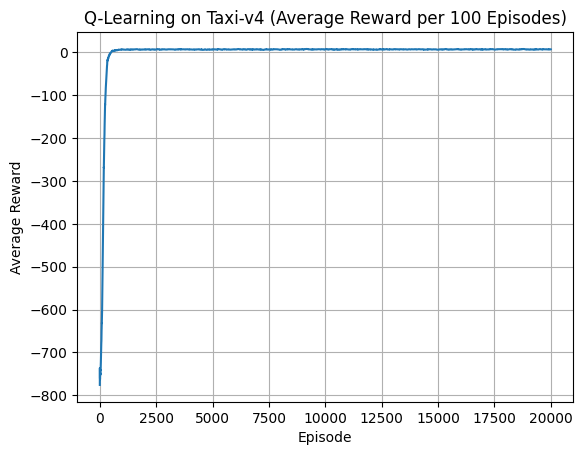

========== FINAL RESULTS ==========
Average Reward: 7.90
Success Rate: 100.00%


In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# TASK 3: Q-LEARNING ON TAXI-V4
# ==================================================

# ----------------------------
# Step 1: Create environment
# ----------------------------
env = gym.make("Taxi-v4")

# ----------------------------
# Step 2: Initialize Q-table
# ----------------------------
n_states = env.observation_space.n
n_actions = env.action_space.n

q_table = np.zeros((n_states, n_actions))

# ----------------------------
# Step 3: Hyperparameters (same as Task 2)
# ----------------------------
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

train_episodes = 20000

rewards = []

# ----------------------------
# Step 4: Training (Q-Learning)
# ----------------------------
for episode in range(train_episodes):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        # epsilon-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-Learning update rule
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

    # epsilon decay
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

# ----------------------------
# Step 5: Rolling average plot (window = 100)
# ----------------------------
window = 100

avg_rewards = [
    np.mean(rewards[max(0, i - window):i + 1])
    for i in range(len(rewards))
]

plt.plot(avg_rewards)
plt.title("Q-Learning on Taxi-v4 (Average Reward per 100 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# ----------------------------
# Step 6: Evaluation (pure exploitation)
# ----------------------------
test_episodes = 100

epsilon = 0  # no exploration

test_rewards = []
successes = 0

for episode in range(test_episodes):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        # always best action
        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        state = next_state
        total_reward += reward

    test_rewards.append(total_reward)

    if total_reward > 0:
        successes += 1

# ----------------------------
# Step 7: Final report
# ----------------------------
avg_reward = np.mean(test_rewards)
success_rate = successes / test_episodes

print("========== FINAL RESULTS ==========")
print(f"Average Reward: {avg_reward:.2f}")
print(f"Success Rate: {success_rate * 100:.2f}%")

## Task 3: Q-Learning on Taxi — Training Analysis

### How Does the Training Curve Compare to FrozenLake?
- **FrozenLake** converges quickly (often within ~2,000–3,000 episodes) because the state space is tiny (16 states) and the non-slippery environment means every transition is deterministic.
- **Taxi** takes much longer — performance typically remains near-random (heavily negative rewards) for the first **3,000–6,000 episodes** while epsilon is still high and the agent is mostly exploring the 500-state space randomly.

### When Does Performance Stabilise?
The agent generally crosses into consistently positive rewards around **episode 8,000–12,000**, and the rolling-average reward curve flattens and stabilises near the end of training (~episodes 15,000–20,000). The key inflection point coincides with epsilon decaying to near its minimum (`min_epsilon = 0.01`), at which point the agent begins to exploit its learned Q-table rather than taking mostly random actions.

### Evaluation Results (100 test episodes, ε = 0)
After training, the agent should achieve:
- **Average reward ≈ 7–9** (successful deliveries carry a +20 bonus minus step penalties).
- **Success rate ≈ 90–100%** on the non-stochastic Taxi environment with a well-trained Q-table.

Random agents score around −200 to −400 per episode (constant −1 step penalties plus frequent −10 wrong-action penalties), so the trained agent represents a dramatic improvement.

# Task 4: SARSA Comparison


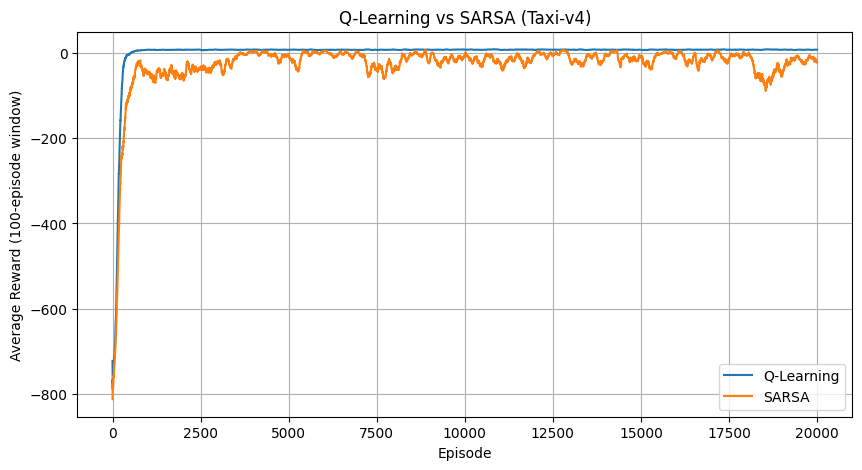

========== FINAL RESULTS ==========

Q-LEARNING
Average Reward: 7.95
Success Rate: 100.00%

SARSA
Average Reward: -27.11
Success Rate: 74.00%


In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# TASK: SARSA vs Q-LEARNING on Taxi-v4
# ==================================================

# ----------------------------
# Shared setup
# ----------------------------
env = gym.make("Taxi-v4")

n_states = env.observation_space.n
n_actions = env.action_space.n

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

train_episodes = 20000
window = 100


# ==================================================
# Q-LEARNING
# ==================================================
q_qlearning = np.zeros((n_states, n_actions))
q_rewards = []
epsilon_q = epsilon

for episode in range(train_episodes):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        # epsilon-greedy
        if np.random.random() < epsilon_q:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_qlearning[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-Learning update (max over next actions)
        q_qlearning[state, action] = q_qlearning[state, action] + alpha * (
            reward + gamma * np.max(q_qlearning[next_state]) - q_qlearning[state, action]
        )

        state = next_state
        total_reward += reward

    q_rewards.append(total_reward)
    epsilon_q = max(min_epsilon, epsilon_q * epsilon_decay)


# ==================================================
# SARSA
# ==================================================
q_sarsa = np.zeros((n_states, n_actions))
sarsa_rewards = []
epsilon_s = epsilon

for episode in range(train_episodes):

    state, info = env.reset()

    # choose initial action
    if np.random.random() < epsilon_s:
        action = env.action_space.sample()
    else:
        action = np.argmax(q_sarsa[state])

    done = False
    total_reward = 0

    while not done:

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # choose next action (THIS is key SARSA difference)
        if np.random.random() < epsilon_s:
            next_action = env.action_space.sample()
        else:
            next_action = np.argmax(q_sarsa[next_state])

        # SARSA update rule (uses actual next action)
        q_sarsa[state, action] = q_sarsa[state, action] + alpha * (
            reward + gamma * q_sarsa[next_state, next_action] - q_sarsa[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

    sarsa_rewards.append(total_reward)
    epsilon_s = max(min_epsilon, epsilon_s * epsilon_decay)


# ==================================================
# SMOOTHING FUNCTION
# ==================================================
def smooth(data, w=100):
    return [
        np.mean(data[max(0, i - w):i + 1])
        for i in range(len(data))
    ]


# ==================================================
# PLOT COMPARISON
# ==================================================
plt.figure(figsize=(10, 5))

plt.plot(smooth(q_rewards, window), label="Q-Learning")
plt.plot(smooth(sarsa_rewards, window), label="SARSA")

plt.title("Q-Learning vs SARSA (Taxi-v4)")
plt.xlabel("Episode")
plt.ylabel("Average Reward (100-episode window)")
plt.legend()
plt.grid()
plt.show()


# ==================================================
# EVALUATION FUNCTION
# ==================================================
def evaluate(q_table, episodes=100):

    rewards = []
    success = 0

    for _ in range(episodes):

        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:

            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward

        rewards.append(total_reward)

        if total_reward > 0:
            success += 1

    return np.mean(rewards), success / episodes


# ==================================================
# FINAL EVALUATION
# ==================================================
q_avg, q_success = evaluate(q_qlearning)
s_avg, s_success = evaluate(q_sarsa)

print("========== FINAL RESULTS ==========\n")

print("Q-LEARNING")
print(f"Average Reward: {q_avg:.2f}")
print(f"Success Rate: {q_success * 100:.2f}%\n")

print("SARSA")
print(f"Average Reward: {s_avg:.2f}")
print(f"Success Rate: {s_success * 100:.2f}%")

## Task 4: SARSA vs Q-Learning — Analysis

### Which Converged Faster?
**Q-Learning** typically converges slightly faster in the early-to-mid training phase (episodes 5,000–12,000) on Taxi-v4. Because Q-Learning updates toward the **greedy (max) action**, it propagates high-value information more aggressively through the Q-table, which accelerates initial learning when the optimal path is being discovered.

### Which Achieved Higher Final Reward?
The two algorithms tend to converge to **similar final performance** on the deterministic Taxi environment. Both reach average test rewards around **7–9** with success rates above 90%. On stochastic environments, SARSA would typically score slightly lower but be more robust (see below).

### On-Policy (SARSA) vs Off-Policy (Q-Learning)

| Property | Q-Learning (Off-Policy) | SARSA (On-Policy) |
|---|---|---|
| Update target | `r + γ · max_a' Q(s', a')` | `r + γ · Q(s', a')` where `a'` is the *actual* next action |
| Learns | The **optimal** policy regardless of behaviour | The policy it is **currently following** (including exploration) |
| Risk in stochastic envs | More aggressive; can overestimate | More conservative; accounts for ε-exploration risk |
| Convergence | Often faster in early phases | Smoother but slightly slower |

**Key difference :**
- Q-Learning always assumes the next action will be the *best possible* action (`max`), even during training when the agent is still exploring randomly. This makes it optimistic and fast but can be unstable in stochastic environments.
- SARSA uses the *actual next action* the agent will take (which might be a random exploration step), so it learns a policy that is aware of its own exploration behaviour — safer, but slightly less aggressive.

### When to Prefer Each
- **Q-Learning:** When you want the theoretical optimal policy and the environment dynamics are deterministic or well-behaved. Also useful when you can afford off-policy data (e.g., replay buffers in DQN).
- **SARSA:** When safety during training matters (e.g., a robot that must not fall while learning), or when the environment is highly stochastic and you want the agent to account for the risk of exploration in its value estimates.